In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (2).png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (285).png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (166)_mask.png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (290)_mask.png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (300).png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (390).png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (357).png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (430)_mask.png
/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/ben

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
filepaths = []
labels = []
class_mapping = {'normal': 0, 'benign': 1, 'malignant': 2}
target_names = ['normal', 'benign', 'malignant']

# Dynamically search Kaggle input directories
for dirname, _, filenames in os.walk('/kaggle/input'):
    folder_name = os.path.basename(dirname).lower()
    if folder_name in class_mapping:
        for filename in filenames:
            if '_mask' not in filename and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepaths.append(os.path.join(dirname, filename))
                labels.append(class_mapping[folder_name])

df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# 70% Train, 15% Val, 15% Test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training Data Class Distribution:")
print(train_df['label'].value_counts().sort_index())

Training Data Class Distribution:
label
0     93
1    306
2    147
Name: count, dtype: int64


In [4]:
class BUSIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Standard Transform (No Augmentation)
std_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_loader = DataLoader(BUSIDataset(val_df, std_transform), batch_size=32, shuffle=False)
test_loader = DataLoader(BUSIDataset(test_df, std_transform), batch_size=32, shuffle=False)

def get_resnet_model():
    """Initializes a fresh ResNet34 model for each experiment."""
    model = models.resnet34(pretrained=True)
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, 3))
    return model.to(device)

def train_experiment(model, train_loader, criterion, exp_name, epochs=10):
    """Reusable training loop."""
    print(f"\n--- Starting {exp_name} ---")
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    best_val_loss = float('inf')
    best_weights = None
    
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += torch.sum(torch.argmax(outputs, 1) == labels.data)
                
        epoch_val_loss = val_loss / len(val_df)
        epoch_val_acc = val_correct.double() / len(val_df)
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = deepcopy(model.state_dict())
            
        print(f"Epoch {epoch+1}/{epochs} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        
    model.load_state_dict(best_weights)
    return model

def evaluate_model(model, title):
    """Evaluates the model on the Test Set and plots Confusion Matrix."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            y_true.extend(labels.numpy())
            y_pred.extend(torch.argmax(outputs, 1).cpu().numpy())
            
    print(f"\nResults for {title}:")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 133MB/s] 



--- Starting Baseline (Standard CE Loss) ---
Epoch 1/10 | Val Loss: 0.7251 | Val Acc: 0.7179
Epoch 2/10 | Val Loss: 0.5895 | Val Acc: 0.7863
Epoch 3/10 | Val Loss: 0.4793 | Val Acc: 0.8205
Epoch 4/10 | Val Loss: 0.4734 | Val Acc: 0.8376
Epoch 5/10 | Val Loss: 0.4770 | Val Acc: 0.8547
Epoch 6/10 | Val Loss: 0.5678 | Val Acc: 0.8205
Epoch 7/10 | Val Loss: 0.6416 | Val Acc: 0.7521
Epoch 8/10 | Val Loss: 0.5358 | Val Acc: 0.8291
Epoch 9/10 | Val Loss: 0.7766 | Val Acc: 0.8120
Epoch 10/10 | Val Loss: 0.6715 | Val Acc: 0.7863

Results for Baseline Confusion Matrix:
              precision    recall  f1-score   support

      normal       0.83      0.50      0.62        20
      benign       0.78      0.94      0.86        66
   malignant       0.81      0.68      0.74        31

    accuracy                           0.79       117
   macro avg       0.81      0.71      0.74       117
weighted avg       0.80      0.79      0.78       117



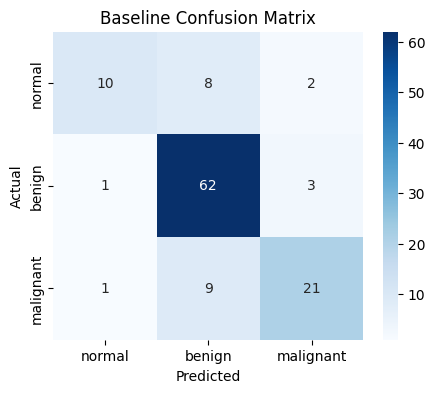

In [5]:
# Create Baseline DataLoader
base_train_loader = DataLoader(BUSIDataset(train_df, std_transform), batch_size=32, shuffle=True)

# Initialize Model & Loss
base_model = get_resnet_model()
ce_loss = nn.CrossEntropyLoss()

# Train & Evaluate
base_model = train_experiment(base_model, base_train_loader, ce_loss, "Baseline (Standard CE Loss)")
evaluate_model(base_model, "Baseline Confusion Matrix")

Undersampled Class Distribution:
 label
0    93
1    93
2    93
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Starting Experiment A (Undersampling) ---
Epoch 1/10 | Val Loss: 0.8569 | Val Acc: 0.6752
Epoch 2/10 | Val Loss: 0.6813 | Val Acc: 0.7436
Epoch 3/10 | Val Loss: 0.6826 | Val Acc: 0.7265
Epoch 4/10 | Val Loss: 0.6881 | Val Acc: 0.7521
Epoch 5/10 | Val Loss: 0.7146 | Val Acc: 0.7350
Epoch 6/10 | Val Loss: 0.7116 | Val Acc: 0.7521
Epoch 7/10 | Val Loss: 0.6349 | Val Acc: 0.7778
Epoch 8/10 | Val Loss: 0.6351 | Val Acc: 0.7949
Epoch 9/10 | Val Loss: 0.6434 | Val Acc: 0.8034
Epoch 10/10 | Val Loss: 0.6465 | Val Acc: 0.8034

Results for Undersampling Confusion Matrix:
              precision    recall  f1-score   support

      normal       0.65      0.85      0.74        20
      benign       0.96      0.74      0.84        66
   malignant       0.68      0.87      0.76        31

    accuracy                           0.79       117
   macro avg       0.76      0.82      0.78       117
weighted avg       0.83      0.79      0.80       117



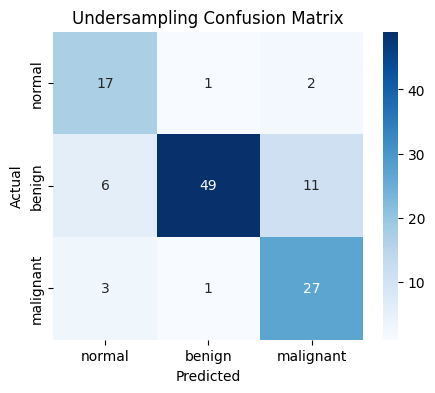

In [6]:
# Find the size of the smallest class
min_class_size = train_df['label'].value_counts().min()

# Undersample the training dataframe
undersampled_df = train_df.groupby('label').sample(n=min_class_size, random_state=42)
print("Undersampled Class Distribution:\n", undersampled_df['label'].value_counts())

# Create Undersampled DataLoader
under_train_loader = DataLoader(BUSIDataset(undersampled_df, std_transform), batch_size=32, shuffle=True)

# Train & Evaluate
under_model = get_resnet_model()
under_model = train_experiment(under_model, under_train_loader, ce_loss, "Experiment A (Undersampling)")
evaluate_model(under_model, "Undersampling Confusion Matrix")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Starting Experiment B (Oversampling) ---
Epoch 1/10 | Val Loss: 0.6671 | Val Acc: 0.7521
Epoch 2/10 | Val Loss: 0.6577 | Val Acc: 0.7521
Epoch 3/10 | Val Loss: 0.5382 | Val Acc: 0.8376
Epoch 4/10 | Val Loss: 0.5415 | Val Acc: 0.8205
Epoch 5/10 | Val Loss: 0.5171 | Val Acc: 0.8462
Epoch 6/10 | Val Loss: 0.6693 | Val Acc: 0.7778
Epoch 7/10 | Val Loss: 0.5174 | Val Acc: 0.8120
Epoch 8/10 | Val Loss: 0.5121 | Val Acc: 0.8718
Epoch 9/10 | Val Loss: 0.5488 | Val Acc: 0.8547
Epoch 10/10 | Val Loss: 0.6056 | Val Acc: 0.8632

Results for Oversampling Confusion Matrix:
              precision    recall  f1-score   support

      normal       1.00      0.55      0.71        20
      benign       0.83      0.97      0.90        66
   malignant       0.86      0.81      0.83        31

    accuracy                           0.85       117
   macro avg       0.90      0.78      0.81       117
weighted avg       0.87      0.85      0.85       117



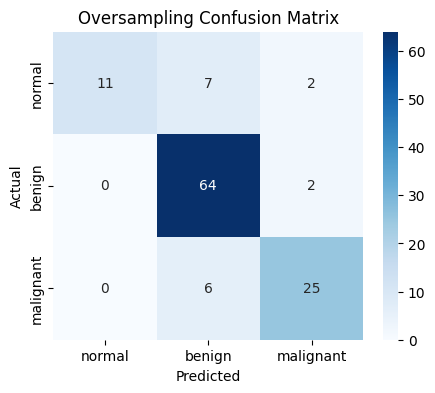

In [7]:
# Calculate weights for each class
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts

# Assign a weight to every single image in the training set based on its class
sample_weights = [class_weights[label] for label in train_df['label']]

# Create the Sampler (Replacement=True allows it to pick the same minority image multiple times)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

# Create DataLoader (NOTE: shuffle MUST be False when using a sampler)
over_train_loader = DataLoader(BUSIDataset(train_df, std_transform), batch_size=32, sampler=sampler)

# Train & Evaluate
over_model = get_resnet_model()
over_model = train_experiment(over_model, over_train_loader, ce_loss, "Experiment B (Oversampling)")
evaluate_model(over_model, "Oversampling Confusion Matrix")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Starting Experiment C (Focal Loss + Aug) ---
Epoch 1/10 | Val Loss: 0.1511 | Val Acc: 0.6838
Epoch 2/10 | Val Loss: 0.1162 | Val Acc: 0.7009
Epoch 3/10 | Val Loss: 0.0837 | Val Acc: 0.7350
Epoch 4/10 | Val Loss: 0.0808 | Val Acc: 0.7863
Epoch 5/10 | Val Loss: 0.0633 | Val Acc: 0.8120
Epoch 6/10 | Val Loss: 0.0705 | Val Acc: 0.7179
Epoch 7/10 | Val Loss: 0.0597 | Val Acc: 0.8376
Epoch 8/10 | Val Loss: 0.0783 | Val Acc: 0.8291
Epoch 9/10 | Val Loss: 0.0519 | Val Acc: 0.8291
Epoch 10/10 | Val Loss: 0.0501 | Val Acc: 0.9145

Results for Focal Loss + Augmentation Confusion Matrix:
              precision    recall  f1-score   support

      normal       0.82      0.90      0.86        20
      benign       0.89      0.86      0.88        66
   malignant       0.81      0.81      0.81        31

    accuracy                           0.85       117
   macro avg       0.84      0.86      0.85       117
weighted avg       0.86      0.85      0.85       117



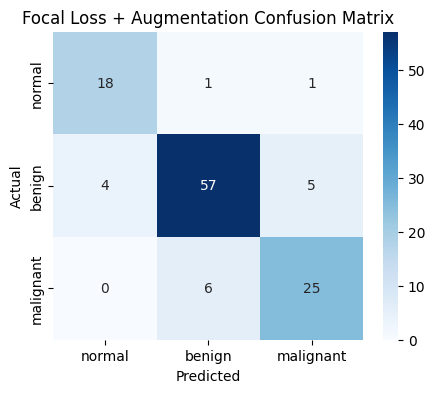

In [8]:
# 1. Apply Data Augmentation to the training set
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
aug_train_loader = DataLoader(BUSIDataset(train_df, aug_transform), batch_size=32, shuffle=True)

# 2. Define Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha.to(device)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha[targets] * (1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

# Calculate Inverse Class Frequencies for the Alpha parameter
alpha_weights = torch.tensor([1.0/c for c in class_counts], dtype=torch.float)
alpha_weights = alpha_weights / alpha_weights.sum() # Normalize

focal_criterion = FocalLoss(alpha=alpha_weights, gamma=2.0)

# Train & Evaluate
focal_model = get_resnet_model()
focal_model = train_experiment(focal_model, aug_train_loader, focal_criterion, "Experiment C (Focal Loss + Aug)")
evaluate_model(focal_model, "Focal Loss + Augmentation Confusion Matrix")